# TP2 - Etapa 2: dataset, preprocesamiento, entrenamiento y comparación de modelos

Notebook de trabajo de la Etapa 2: análisis del dataset, preprocesamiento,
fine-tuning de ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B,
obligatorio) y estudio comparativo.

Puede ejecutarse en Google Colab con GPU o localmente mediante Jupyter. En esta
máquina virtual se utilizará el Python del sistema y PyTorch CPU.

Requisitos previos:
- `train_classifier` y `evaluate_classifier` implementadas en
  `src/lib/services/classifier_service.py`.
- Dependencias del proyecto instaladas.
- Dataset disponible o credenciales de Kaggle configuradas para descargarlo.

Al finalizar:
- Conservar los dos checkpoints generados en `models/`.
- Entregar esta notebook ejecutada con sus salidas.


## Equipo
- Alumno 1: Agustín Accurso
- Alumno 2: Lautaro Cena

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [3]:
import os
import sys
import subprocess
from pathlib import Path


REPO_URL = "https://github.com/accursoagus/tuia-dog-recognition-app.git"
REPO_BRANCH = "desarrollo"

IN_COLAB = "google.colab" in sys.modules


def find_project_root(start_path: Path) -> Path | None:
    """
    Busca la raíz del repositorio comprobando que existan
    las carpetas src y scripts.
    """
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate

    return None


project_root = find_project_root(Path.cwd())


if project_root is None and IN_COLAB:
    colab_project_path = Path("/content/proyecto")

    if not colab_project_path.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "-b",
                REPO_BRANCH,
                REPO_URL,
                str(colab_project_path),
            ],
            check=True,
        )
    else:
        print(
            "El directorio del proyecto ya existe en Colab; "
            "se reutiliza."
        )

    project_root = find_project_root(colab_project_path)


if project_root is None:
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. "
        "Abrí la notebook desde la carpeta del proyecto o "
        "ejecutala en Google Colab."
    )


ROOT = project_root
SRC = ROOT / "src"

os.chdir(ROOT)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


print(f"Entorno: {'Google Colab' if IN_COLAB else 'local'}")
print(f"Raíz del proyecto: {ROOT}")

Entorno: Google Colab
Raíz del proyecto: /content/proyecto


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [4]:
if IN_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pydantic-settings",
            "python-dotenv",
            "kagglehub",
            "albumentations",
            "onnxruntime",
        ]
    )
else:
    print(
        "Entorno local: se reutilizan las dependencias ya "
        "instaladas desde requirements.txt."
    )


In [5]:
from collections import Counter
import random
import re
import shutil
import time
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from dotenv import load_dotenv
from IPython.display import Markdown, display
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ------------------------------------------------------------
# Configuración mediante variables de entorno
# ------------------------------------------------------------

# La Etapa 2 no utiliza la base vectorial.
os.environ["USE_PGVECTOR"] = "false"

# Ruta portable dentro del repositorio.
os.environ.setdefault(
    "DATASET_PATH",
    str(ROOT / "data" / "dataset"),
)

# Cargar configuración externa cuando exista. El archivo example
# se usa como fallback en Colab para valores públicos no sensibles.
env_candidates = [
    SRC / ".env",
    ROOT / ".env",
    ROOT / ".env.local",
    ROOT / ".env.local.example",
]

loaded_env = None

for env_path in env_candidates:
    if env_path.is_file():
        load_dotenv(env_path, override=False)
        loaded_env = env_path
        break

from lib.services.classifier_service import (
    IMAGENET_MEAN,
    IMAGENET_STD,
)
from lib.config import settings
from lib.bootstrap import build_classifier

OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Configuración externa cargada: {loaded_env}")
print(f"Dataset configurado: {settings.dataset_path}")
print(f"Directorio de salidas: {OUTPUT_DIR}")
print(
    f"Existe train: "
    f"{(settings.dataset_path / 'train').exists()}"
)
print(
    f"Dispositivo disponible: "
    f"{'CUDA' if torch.cuda.is_available() else 'CPU'}"
)

# En Colab, esta etapa debe ejecutarse con GPU.
# Evita perder horas por haber dejado el runtime en CPU.
if IN_COLAB and not torch.cuda.is_available():
    raise RuntimeError(
        "Google Colab está usando CPU. "
        "Seleccioná Entorno de ejecución > Cambiar tipo de entorno > T4 GPU "
        "y volvé a ejecutar desde el inicio."
    )


Configuración externa cargada: /content/proyecto/.env.local.example
Dataset configurado: /content/proyecto/data/dataset
Directorio de salidas: /content/proyecto/output
Existe train: False
Dispositivo disponible: CUDA


## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dejar ambos en True para esta ejecución completa.
# Después de obtener y guardar las salidas, cambiarlos a False
# evita reentrenar por accidente al ejecutar nuevamente la notebook.
TRAIN_RESNET18 = True
TRAIN_CNN_CUSTOM = True

print(f"Seed fijada en {SEED}.")
print(f"Entrenar ResNet18: {TRAIN_RESNET18}")
print(f"Entrenar CNN Custom: {TRAIN_CNN_CUSTOM}")


Seed fijada en 42.
Entrenar ResNet18: True
Entrenar CNN Custom: True


## 4. Descargar el dataset

In [7]:
dataset_download_script = ROOT / "scripts" / "download_dataset.py"

if not (settings.dataset_path / "train").is_dir():
    subprocess.run(
        [
            sys.executable,
            str(dataset_download_script),
        ],
        check=True,
        cwd=ROOT,
    )
else:
    print(
        "Dataset ya presente; se omite la descarga."
    )

available_items = sorted(
    path.name
    for path in settings.dataset_path.iterdir()
)

print("Contenido del dataset:", available_items)


Contenido del dataset: ['.gitkeep', 'dogs.csv', 'test', 'train', 'valid']


## 5. Analisis del dataset


### Definir conjuntos de entrenamiento, validacion y prueba, y analizar la distribucion de clases, documentando cantidad de imagenes por raza.

In [8]:
required_splits = ("train", "valid", "test")

missing_splits = [
    split
    for split in required_splits
    if not (settings.dataset_path / split).is_dir()
]

if missing_splits:
    raise FileNotFoundError(
        "Faltan splits del dataset: "
        f"{missing_splits}"
    )

print(
    "Dataset verificado en:",
    settings.dataset_path,
)


Dataset verificado en: /content/proyecto/data/dataset


In [9]:
print(settings.dataset_path)
print(settings.dataset_path.exists())
print(list(settings.dataset_path.parent.iterdir()) if settings.dataset_path.parent.exists() else "ni el padre existe")

/content/proyecto/data/dataset
True
[PosixPath('/content/proyecto/data/dataset')]


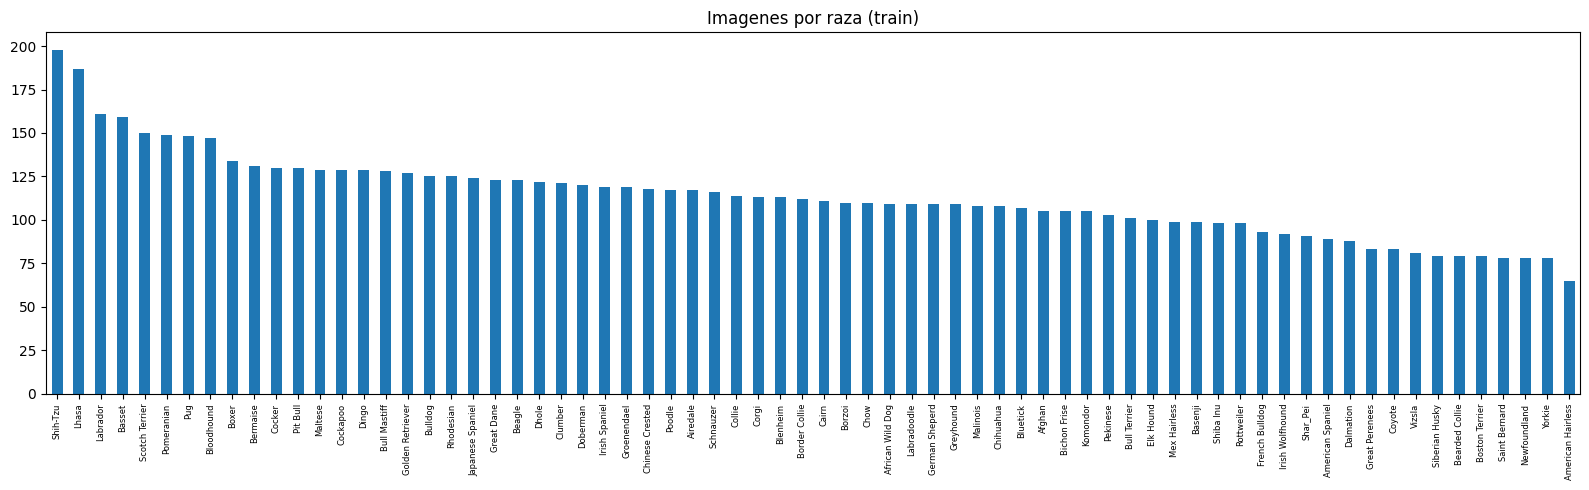

Total razas: 70
Min/Max imagenes por raza: 65 / 198
Promedio de imagenes por raza: 113.5
Desvio estandar: 24.7
Razas con menos de 100 imagenes: 19 de 70
train: 7946 imagenes, 70 razas
valid: 700 imagenes, 70 razas
test: 700 imagenes, 70 razas


In [10]:
breeds = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
counts = {b: len(list((settings.dataset_path / "train" / b).glob("*.jpg"))) for b in breeds}

df_counts = pd.Series(counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
df_counts.plot(kind="bar", ax=ax, title="Imagenes por raza (train)")
ax.set_xticklabels(df_counts.index, rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution_etapa2.png", dpi=100)
plt.show()

print(f"Total razas: {len(breeds)}")
print(f"Min/Max imagenes por raza: {df_counts.min()} / {df_counts.max()}")
print(f"Promedio de imagenes por raza: {df_counts.mean():.1f}")
print(f"Desvio estandar: {df_counts.std():.1f}")
print(f"Razas con menos de 100 imagenes: {(df_counts < 100).sum()} de {len(df_counts)}")

for split in ("train", "valid", "test"):
    split_path = settings.dataset_path / split
    n_images = sum(1 for _ in split_path.rglob("*.jpg"))
    n_breeds = sum(1 for p in split_path.iterdir() if p.is_dir())
    print(f"{split}: {n_images} imagenes, {n_breeds} razas")

### Conjunto de validación externa:

In [11]:
EXTERNAL_SET_PATH = (
    settings.dataset_path.parent
    / "external_eval"
)


def count_external_images(path: Path) -> int:
    return sum(
        1
        for item in path.rglob("*")
        if item.suffix.lower()
        in {".jpg", ".jpeg", ".png"}
    )


n_external_existing = (
    count_external_images(EXTERNAL_SET_PATH)
    if EXTERNAL_SET_PATH.is_dir()
    else 0
)


if n_external_existing == 0:
    file_id = settings.external_dataset_file_id

    if not file_id:
        raise ValueError(
            "Falta configurar EXTERNAL_DATASET_FILE_ID "
            "en src/.env o .env.local.example."
        )

    shutil.rmtree(
        EXTERNAL_SET_PATH,
        ignore_errors=True,
    )
    EXTERNAL_SET_PATH.mkdir(
        parents=True,
        exist_ok=True,
    )

    direct_url = (
        "https://drive.google.com/uc"
        f"?export=download&id={file_id}"
    )
    zip_path = (
        EXTERNAL_SET_PATH
        / "temp_dataset.zip"
    )

    urllib.request.urlretrieve(
        direct_url,
        zip_path,
    )

    with zipfile.ZipFile(
        zip_path,
        "r",
    ) as zip_ref:
        zip_ref.extractall(
            EXTERNAL_SET_PATH
        )

    zip_path.unlink(missing_ok=True)

else:
    print(
        "Conjunto externo ya presente; "
        "se reutiliza sin volver a descargar."
    )


n_external = count_external_images(
    EXTERNAL_SET_PATH
)

external_breeds = sorted(
    path.name
    for path in EXTERNAL_SET_PATH.iterdir()
    if path.is_dir()
)

if n_external == 0:
    raise RuntimeError(
        "El conjunto externo quedó vacío."
    )

print(
    f"Conjunto externo: {n_external} imágenes, "
    f"{len(external_breeds)} razas"
)
print("Razas externas:", external_breeds)


Conjunto externo: 26 imágenes, 5 razas
Razas externas: ['Basset', 'Border Collie', 'Doberman', 'Golden Retriever', 'Poodle']


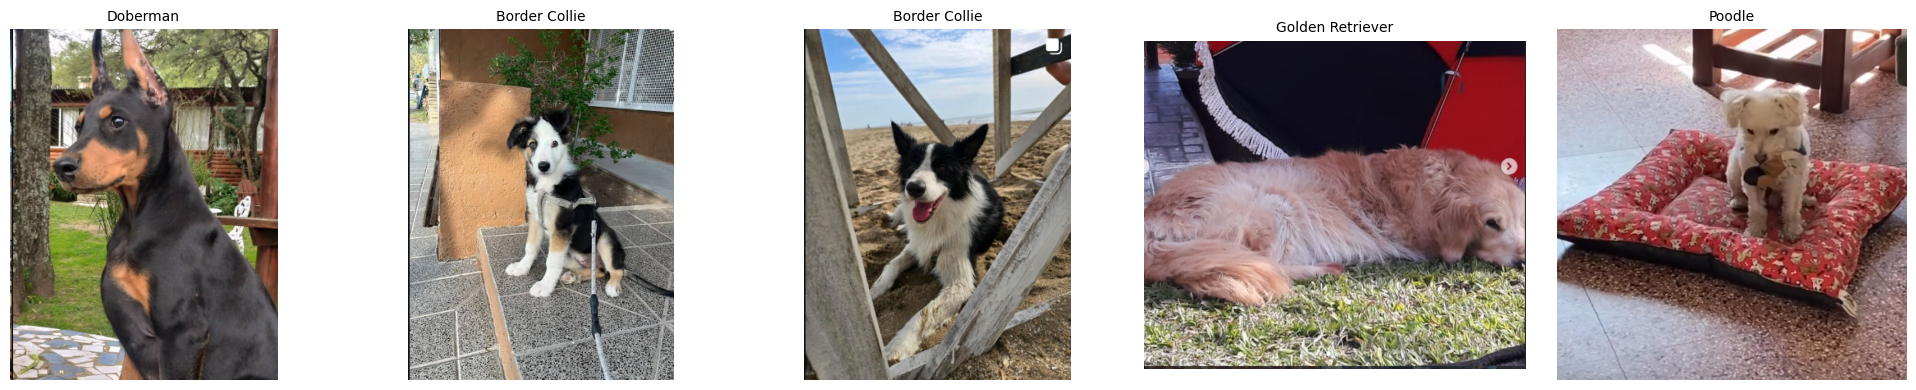

In [12]:
todas_las_imgs = list(EXTERNAL_SET_PATH.rglob("*.png")) + list(EXTERNAL_SET_PATH.rglob("*.jpg"))
muestra = random.sample(todas_las_imgs, min(5, len(todas_las_imgs)))

fig, axes = plt.subplots(1, len(muestra), figsize=(4 * len(muestra), 4))
if len(muestra) == 1:
    axes = [axes]
for ax, img_path in zip(axes, muestra):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(img_path.parent.name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "external_eval_sample.png", dpi=100)
plt.show()

### Conclusiones del análisis exploratorio — Etapa 2

El conjunto de entrenamiento contiene **7.946 imágenes distribuidas en 70
razas**, con entre **65 y 198 imágenes por clase**. El promedio es de
aproximadamente **113,5 imágenes por raza**, y **19 de las 70 clases**
poseen menos de 100 ejemplos. Por lo tanto, existe un desbalance moderado que
debe considerarse al interpretar las métricas por clase.

En la Etapa 2, este desbalance puede influir directamente en el aprendizaje,
porque los modelos actualizan sus parámetros a partir de la distribución de
`train`. Las clases con menos ejemplos aportan menos actualizaciones durante
el entrenamiento y podrían presentar menor recall o mayor variabilidad en sus
resultados. Esta posibilidad se comprobará posteriormente mediante las métricas
por clase y las matrices de confusión, sin asumir de antemano que todas las
clases minoritarias necesariamente tendrán peor desempeño.

El desbalance también puede afectar la Etapa 1, aunque de una manera diferente.
El extractor preentrenado no se ajusta con este dataset, por lo que la
distribución de clases no modifica sus pesos. Sin embargo, las clases con mayor
cantidad de imágenes tienen una representación más numerosa en la base
vectorial y, por lo tanto, pueden aparecer con mayor frecuencia entre los
vecinos recuperados y participar más veces en la predicción por similitud.

Los conjuntos `valid` y `test` se mantienen separados de `train`, y además se
construyó un conjunto externo de **26 imágenes pertenecientes a 5 razas**.
Este conjunto externo se utilizará como evaluación complementaria de
generalización, pero no reemplaza al conjunto de prueba principal porque no
representa las 70 clases del problema.

## 6. Preprocesamiento

### Filtrado de imagenes de baja calidad
**Criterio**: descartar imagenes corruptas (no abren con PIL) o con resolucion por debajo de un minimo razonable para el resize a self.image_size.

In [13]:
MIN_RESOLUTION = 64  # px por lado, umbral minimo aceptado

def filtrar_imagenes_baja_calidad(dataset_path, splits=("train", "valid", "test"), min_resolution=MIN_RESOLUTION):
    """
    Recorre cada split y elimina imagenes corruptas o de resolucion
    insuficiente. Devuelve un detalle de lo eliminado para documentar
    en el informe.
    """
    eliminadas = []
    for split in splits:
        split_path = dataset_path / split
        for img_path in split_path.rglob("*.jpg"):
            try:
                with Image.open(img_path) as img:
                    img.verify()
                with Image.open(img_path) as img:
                    w, h = img.size
                    if w < min_resolution or h < min_resolution:
                        eliminadas.append((split, img_path.name, f"resolucion {w}x{h}"))
                        img_path.unlink()
            except Exception as e:
                eliminadas.append((split, img_path.name, f"corrupta: {e}"))
                img_path.unlink(missing_ok=True)
    return eliminadas

eliminadas = filtrar_imagenes_baja_calidad(settings.dataset_path)
print(f"Imagenes eliminadas por baja calidad: {len(eliminadas)}")
for split, nombre, motivo in eliminadas[:20]:
    print(f"  [{split}] {nombre}: {motivo}")

Imagenes eliminadas por baja calidad: 0


In [14]:
if eliminadas:
    quality_result = (
        f"Se eliminaron **{len(eliminadas)} imágenes** "
        "corruptas o con resolución menor a "
        f"{MIN_RESOLUTION}px en alguno de sus lados."
    )
else:
    quality_result = (
        "No se eliminaron imágenes: todos los archivos "
        "pudieron abrirse y superaron el umbral mínimo "
        f"de {MIN_RESOLUTION}px por lado."
    )

display(
    Markdown(
        f"""
### Resultado del filtrado de calidad

{quality_result}

El umbral se utiliza para evitar que el `resize` amplíe
excesivamente imágenes muy pequeñas. El control se aplica
sobre `train`, `valid` y `test` antes del entrenamiento.
"""
    )
)



### Resultado del filtrado de calidad

No se eliminaron imágenes: todos los archivos pudieron abrirse y superaron el umbral mínimo de 64px por lado.

El umbral se utiliza para evitar que el `resize` amplíe
excesivamente imágenes muy pequeñas. El control se aplica
sobre `train`, `valid` y `test` antes del entrenamiento.


### Resize, normalizacion y data augmentation

- **Resize:** todas las imagenes se redimensionan a `image_size x image_size`
  (configurable via `.env`), tamaño compatible con la entrada esperada por
  ResNet18 preentrenado en ImageNet.
- **Normalizacion:** se usan media y desvio estandar de ImageNet
  (`IMAGENET_MEAN`, `IMAGENET_STD`), ya que el Modelo A reutiliza pesos
  preentrenados en ese dataset; mantener la misma normalizacion con la que
  el backbone fue originalmente entrenado evita un corrimiento de
  distribucion que degradaria el fine-tuning. Se aplica la misma
  normalizacion al Modelo B (CNN propia, sin pesos preentrenados) por
  consistencia y simplicidad, aunque en ese caso no es estrictamente
  necesaria.
- **Data Augmentation (solo en train):**
  - Horizontal Flip (p=0.5): las razas de perro no tienen una orientacion
    canonica relevante, por lo que espejar horizontalmente es una
    transformacion valida que no distorsiona la clase.
  - Rotacion (±15°): simula variacion natural en el angulo de toma de
    la foto, sin rotar tanto como para deformar la pose del animal.
  - Variaciones de brillo y contraste (ColorJitter, ±0.2): compensa
    diferencias de iluminacion entre fotos (interior/exterior, distintas
    camaras).

No se implementaron blur ni inyeccion de ruido como augmentation. Se evaluo
que, para un problema de clasificacion de razas (donde el detalle textural
del pelaje es informativo), introducir blur o ruido sintetico podria
degradar features relevantes sin un beneficio claro de generalizacion
adicional al ya aportado por flip, rotacion y color jitter. Se prioriza
augmentation que simula variabilidad real de captura (angulo, iluminacion)
sobre degradacion sintetica de la imagen.

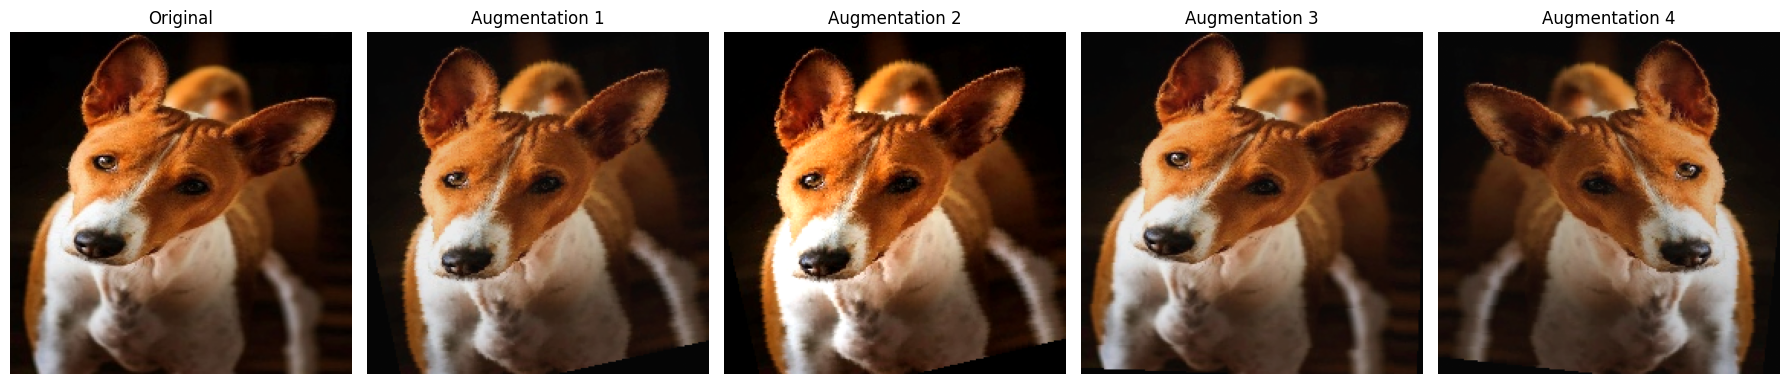

In [15]:
classifier_preview = build_classifier(settings)
train_tf = classifier_preview._build_transforms(train=True)
valid_tf = classifier_preview._build_transforms(train=False)

# Tomamos una imagen de ejemplo
sample_breed = breeds[5]
sample_path = next((settings.dataset_path / "train" / sample_breed).glob("*.*"))

img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
for i in range(1, 5):
    augmented = train_tf(img)
    # des-normalizar para visualizar
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1) if 'IMAGENET_MEAN' in dir() else torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1) if 'IMAGENET_STD' in dir() else torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    denorm = (augmented * std + mean).clamp(0,1).permute(1,2,0).numpy()
    axes[i].imshow(denorm)
    axes[i].set_title(f"Augmentation {i}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "augmentation_examples.png", dpi=100)
plt.show()

### Normalizacion de nombres de carpetas

Se detecto una inconsistencia en los nombres de carpetas de razas entre
splits (ej. espacios dobles en `valid` vs `train`), que `ImageFolder`
trata como clases distintas. Se normalizan los espacios antes de
entrenar para evitar este desajuste.

In [16]:
def normalizar_nombres_carpetas(dataset_path, splits=("train", "valid", "test")):
    """
    Normaliza espacios múltiples a uno solo en los nombres de carpetas de
    cada raza, en los tres splits. Necesario porque el dataset de Kaggle
    tiene inconsistencias (ej. 'American Spaniel' vs 'American  Spaniel').
    """
    renombradas = []
    for split in splits:
        split_path = dataset_path / split
        for breed_dir in sorted(split_path.iterdir()):
            if not breed_dir.is_dir():
                continue
            nombre_normalizado = re.sub(r"\s+", " ", breed_dir.name).strip()
            if nombre_normalizado != breed_dir.name:
                destino = split_path / nombre_normalizado
                breed_dir.rename(destino)
                renombradas.append((split, breed_dir.name, nombre_normalizado))
    return renombradas

cambios = normalizar_nombres_carpetas(settings.dataset_path)
for split, antes, despues in cambios:
    print(f"[{split}] '{antes}' -> '{despues}'")
print(f"\nTotal carpetas renombradas: {len(cambios)}")

# Verificacion: confirmar que ahora coinciden entre splits
train_classes = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
valid_classes = sorted(p.name for p in (settings.dataset_path / "valid").iterdir() if p.is_dir())
test_classes = sorted(p.name for p in (settings.dataset_path / "test").iterdir() if p.is_dir())

assert train_classes == valid_classes == test_classes, "Todavia hay inconsistencias entre splits"
print("Clases consistentes entre train/valid/test:", len(train_classes))

[valid] 'American  Spaniel' -> 'American Spaniel'

Total carpetas renombradas: 1
Clases consistentes entre train/valid/test: 70


## 7. Modelo A (obligatorio): fine-tuning de ResNet18

**Hiperparametros utilizados:**

| Parametro | Valor | Justificacion |
|---|---|---|
| Batch size | 32 | Balance entre estabilidad del gradiente y memoria disponible en GPU T4 de Colab. |
| Epochs maximas | 15 | Suficiente para converger con early stopping; se evito un numero mayor para no incurrir en tiempo de entrenamiento innecesario. |
| Patience | 4 | Tolerancia de 4 epochs sin mejora en valid_loss antes de detener, evitando overfitting sin cortar prematuramente. |
| LR head (fc) | 1e-3 | Learning rate mas alto para la capa final, que se entrena desde cero. |
| LR backbone (layer4) | 1e-4 | Learning rate mas bajo para las capas preentrenadas que se descongelan, evitando destruir features ya aprendidas en ImageNet (fine-tuning conservador). |
| Step size (scheduler) | 5 | El LR decae cada 5 epochs. |
| Gamma (scheduler) | 0.5 | El LR se reduce a la mitad en cada decay, permitiendo ajuste fino en epochs tardias. |

Arquitectura: solo se descongelan `layer4` y la capa `fc` final de ResNet18;
el resto del backbone permanece congelado, ya que las capas iniciales
capturan features genericas (bordes, texturas) reutilizables sin
reentrenamiento, mientras que `layer4` captura features mas especificas
que conviene adaptar al dominio de razas de perros.

No se realizó búsqueda de hiperparámetros (LR, batch size, etc.) para el
Modelo A; los valores de la tabla fueron elegidos por criterio razonado
(justificado de la tabla) y no ajustados empíricamente mediante
grid search o similar, por motivos de tiempo y costo de cómputo. El
checkpoint guardado corresponde al de menor valid_loss, no al de mayor
valid_acc; se verifica en la sección de Estudio Comparativo si ambos
criterios coinciden en la práctica para este dataset.

In [17]:
classifier = build_classifier(settings)
classifier.set_active_model(
    "resnet18_finetuned"
)

resnet_checkpoint_path = (
    settings.model_path
    / settings.resnet18_model_name
)

if TRAIN_RESNET18:
    classifier.train_classifier()

elif not resnet_checkpoint_path.is_file():
    raise FileNotFoundError(
        "TRAIN_RESNET18=False, pero no existe "
        f"el checkpoint: {resnet_checkpoint_path}"
    )

else:
    print(
        "Se reutiliza el checkpoint existente de "
        "ResNet18."
    )


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


In [18]:
# Respaldo inmediato del Modelo A antes de continuar.
resnet_checkpoint_path = (
    settings.model_path
    / settings.resnet18_model_name
)

if not resnet_checkpoint_path.is_file():
    raise FileNotFoundError(
        f"No se generó el checkpoint de ResNet18: {resnet_checkpoint_path}"
    )

print(
    "Checkpoint ResNet18 guardado:",
    resnet_checkpoint_path.resolve(),
    f"({resnet_checkpoint_path.stat().st_size / (1024 ** 2):.2f} MB)",
)

if IN_COLAB:
    from google.colab import files
    files.download(str(resnet_checkpoint_path))

Checkpoint ResNet18 guardado: /content/models/resnet18_finetuned.pth (42.85 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
metrics_a = classifier.evaluate_classifier()
metrics_a

{'accuracy': 0.9585714285714285,
 'precision': 0.9600778190063904,
 'recall': 0.9585714285714287,
 'specificity': 0.999399585921325,
 'f1': 0.9566340092655882}

In [20]:
checkpoint = torch.load(classifier.active_checkpoint, map_location="cpu", weights_only=False)
history = checkpoint["history"]

### Curvas de entrenamiento y matriz de confusion (Modelo A)


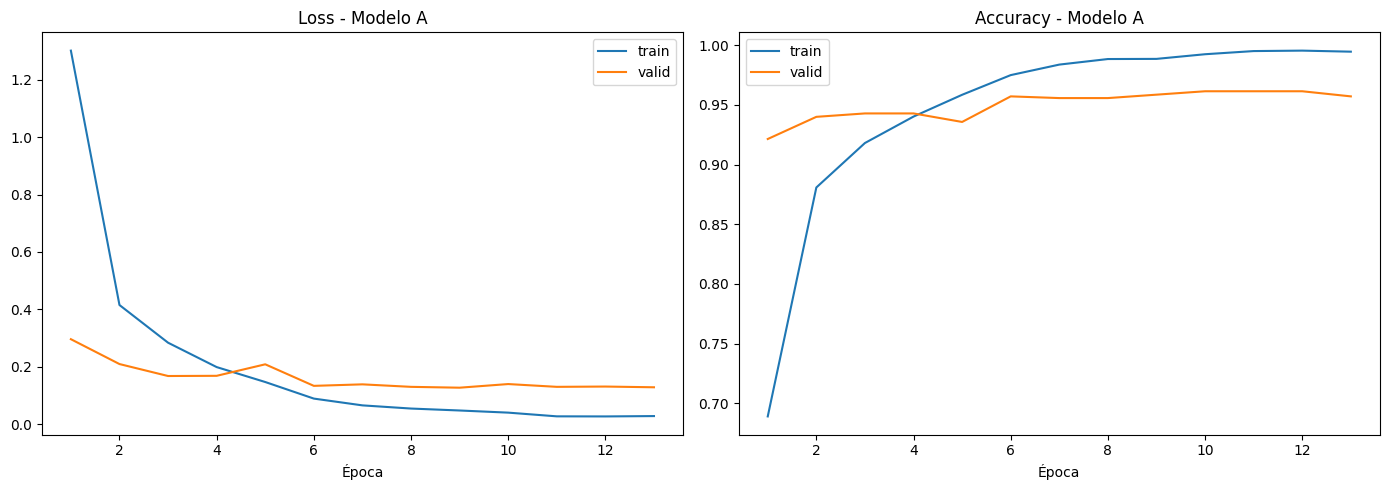

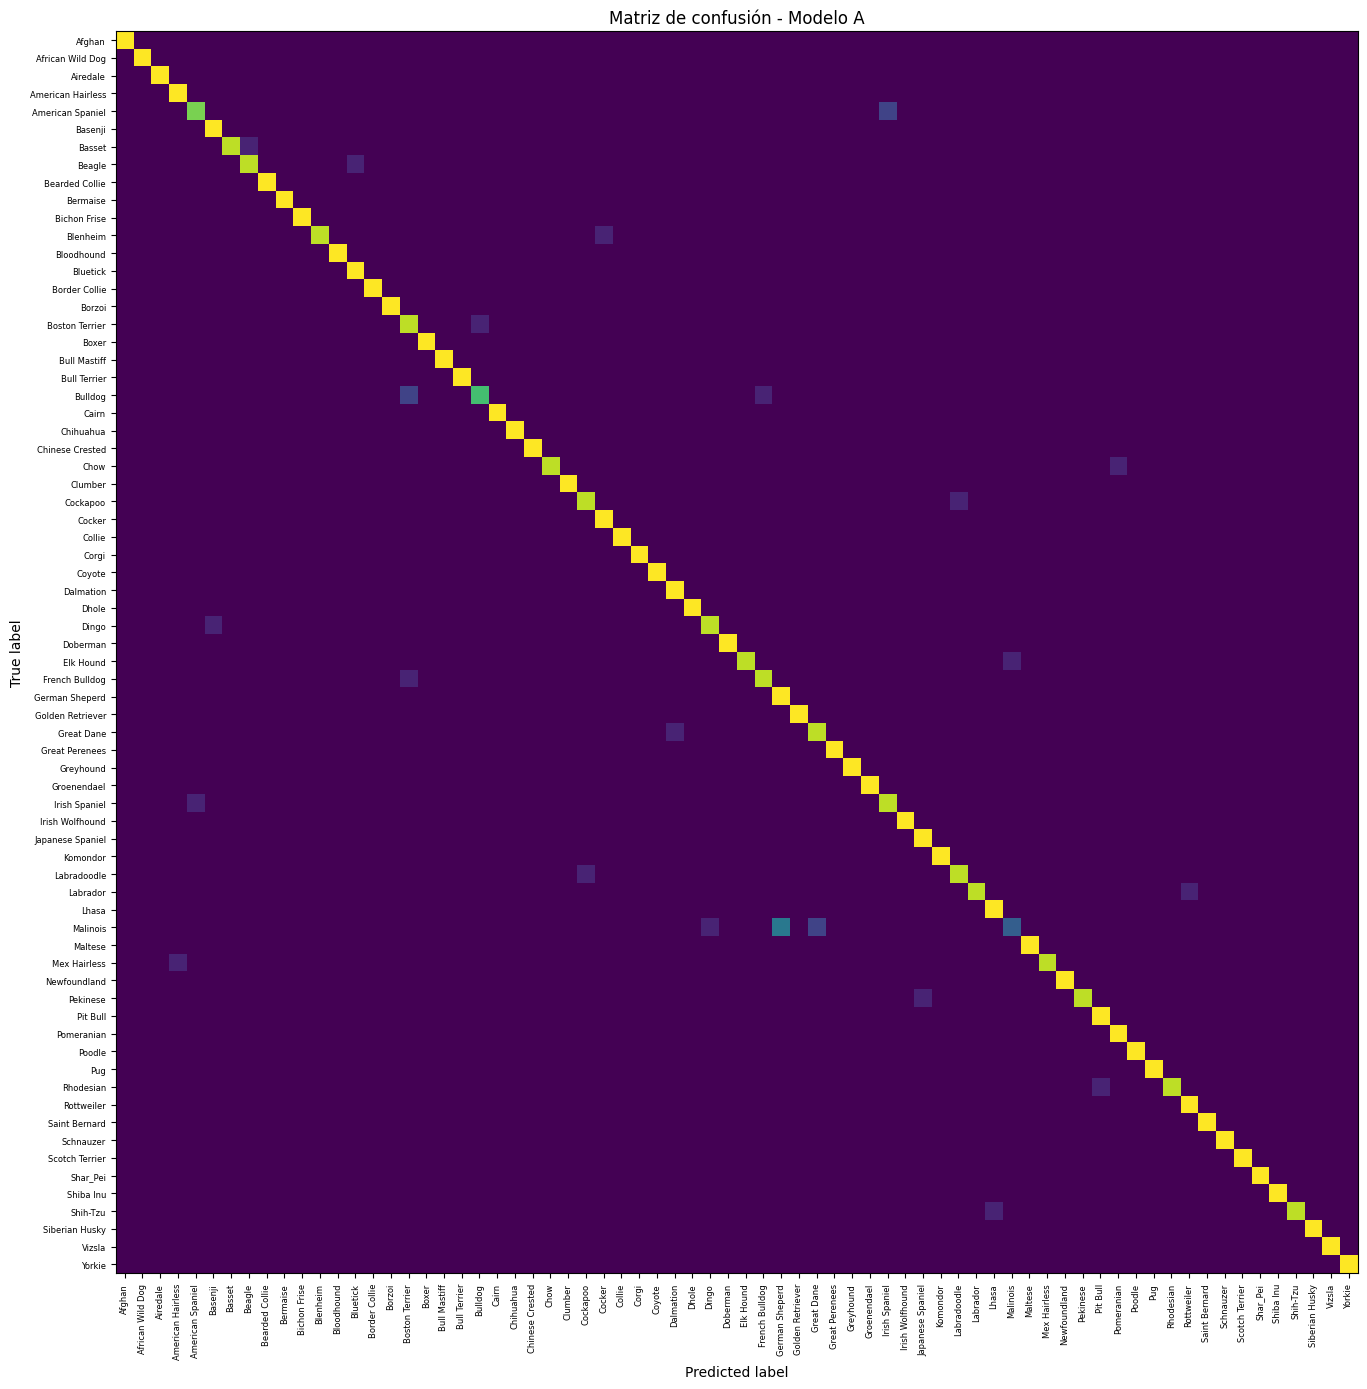

In [21]:
checkpoint_a = torch.load(
    settings.model_path
    / settings.resnet18_model_name,
    map_location="cpu",
    weights_only=False,
)
history_a = checkpoint_a["history"]

epochs_axis_a = range(
    1,
    len(history_a["train_loss"]) + 1,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs_axis_a,
    history_a["train_loss"],
    label="train",
)
axes[0].plot(
    epochs_axis_a,
    history_a["valid_loss"],
    label="valid",
)
axes[0].set_title(
    "Loss - Modelo A"
)
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(
    epochs_axis_a,
    history_a["train_acc"],
    label="train",
)
axes[1].plot(
    epochs_axis_a,
    history_a["valid_acc"],
    label="valid",
)
axes[1].set_title(
    "Accuracy - Modelo A"
)
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "curves_model_a.png",
    dpi=100,
)
plt.show()


# Matriz de confusión sobre test
class_names = checkpoint_a["class_names"]

model_a = (
    classifier._build_resnet18_finetuned(
        len(class_names)
    )
)
model_a.load_state_dict(
    checkpoint_a["model_state_dict"]
)
model_a.eval()

test_tf = classifier._build_transforms(
    train=False
)
test_ds = datasets.ImageFolder(
    settings.dataset_path / "test",
    transform=test_tf,
)
test_loader = DataLoader(
    test_ds,
    batch_size=settings.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(
            classifier.device
        )
        outputs = model_a(images)

        all_preds.extend(
            outputs.argmax(1)
            .cpu()
            .numpy()
        )
        all_labels.extend(
            labels.numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_preds,
)

fig, ax = plt.subplots(
    figsize=(16, 14)
)

display_cm_a = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

display_cm_a.plot(
    ax=ax,
    xticks_rotation=90,
    include_values=False,
    colorbar=False,
)

ax.set_title(
    "Matriz de confusión - Modelo A"
)
ax.tick_params(
    axis="both",
    labelsize=6,
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "confusion_matrix_a.png",
    dpi=100,
)
plt.show()


In [22]:
epochs_a = len(
    history_a["train_loss"]
)

best_valid_loss_index_a = int(
    np.argmin(
        history_a["valid_loss"]
    )
)
best_valid_acc_index_a = int(
    np.argmax(
        history_a["valid_acc"]
    )
)

best_valid_loss_epoch_a = (
    best_valid_loss_index_a + 1
)
best_valid_acc_epoch_a = (
    best_valid_acc_index_a + 1
)

final_train_loss_a = float(
    history_a["train_loss"][-1]
)
final_valid_loss_a = float(
    history_a["valid_loss"][-1]
)
final_train_acc_a = float(
    history_a["train_acc"][-1]
)
final_valid_acc_a = float(
    history_a["valid_acc"][-1]
)

samples_per_class_a = cm.sum(axis=1)

recall_per_class_a = np.divide(
    np.diag(cm),
    samples_per_class_a,
    out=np.zeros_like(
        samples_per_class_a,
        dtype=float,
    ),
    where=samples_per_class_a != 0,
)

worst_indices_a = np.argsort(
    recall_per_class_a
)[:5]

confusion_lines_a = []

for class_index in worst_indices_a:
    row = cm[class_index].copy()
    row[class_index] = 0

    confused_index = int(
        np.argmax(row)
    )
    confused_amount = int(
        row[confused_index]
    )

    class_name = class_names[class_index]
    class_recall = recall_per_class_a[
        class_index
    ]

    if confused_amount > 0:
        confusion_lines_a.append(
            f"- **{class_name}**: recall "
            f"{class_recall:.2f}; principal confusión "
            f"con **{class_names[confused_index]}** "
            f"({confused_amount} imágenes)."
        )
    else:
        confusion_lines_a.append(
            f"- **{class_name}**: recall "
            f"{class_recall:.2f}; sin una confusión "
            "predominante única."
        )


if (
    best_valid_loss_epoch_a == epochs_a
    or best_valid_acc_epoch_a == epochs_a
):
    convergence_interpretation_a = (
        "El mejor valor de validación se obtuvo al final "
        "del entrenamiento, por lo que no aparece una señal "
        "clara de deterioro posterior."
    )

elif (
    final_valid_loss_a
    > history_a["valid_loss"][
        best_valid_loss_index_a
    ]
    and final_train_loss_a
    < history_a["train_loss"][
        best_valid_loss_index_a
    ]
):
    convergence_interpretation_a = (
        "Después del menor `valid_loss`, la pérdida de "
        "entrenamiento continuó bajando mientras la de "
        "validación empeoró. Esto es compatible con una "
        "etapa posterior de sobreajuste."
    )

else:
    convergence_interpretation_a = (
        "Las curvas muestran una evolución estable, sin "
        "evidencia suficiente para afirmar sobreajuste."
    )


display(
    Markdown(
        f"""
### Análisis Modelo A - ResNet18 Fine-Tuned

ResNet18 ejecutó **{epochs_a} épocas**. Al finalizar,
alcanzó una accuracy de entrenamiento de
**{final_train_acc_a:.4f}** y una accuracy de validación de
**{final_valid_acc_a:.4f}**. La pérdida final fue
**{final_train_loss_a:.4f}** en entrenamiento y
**{final_valid_loss_a:.4f}** en validación.

El menor `valid_loss` se obtuvo en la época
**{best_valid_loss_epoch_a}**, mientras que la mayor
`valid_acc` se obtuvo en la época
**{best_valid_acc_epoch_a}**.

{convergence_interpretation_a}

Las cinco clases con menor recall fueron:

{chr(10).join(confusion_lines_a)}

El análisis se construye a partir de esta ejecución y no
presupone qué razas deben confundirse por similitud visual.
"""
    )
)



### Análisis Modelo A - ResNet18 Fine-Tuned

ResNet18 ejecutó **13 épocas**. Al finalizar,
alcanzó una accuracy de entrenamiento de
**0.9946** y una accuracy de validación de
**0.9571**. La pérdida final fue
**0.0279** en entrenamiento y
**0.1283** en validación.

El menor `valid_loss` se obtuvo en la época
**9**, mientras que la mayor
`valid_acc` se obtuvo en la época
**10**.

Después del menor `valid_loss`, la pérdida de entrenamiento continuó bajando mientras la de validación empeoró. Esto es compatible con una etapa posterior de sobreajuste.

Las cinco clases con menor recall fueron:

- **Malinois**: recall 0.30; principal confusión con **German Sheperd** (4 imágenes).
- **Bulldog**: recall 0.70; principal confusión con **Boston Terrier** (2 imágenes).
- **American Spaniel**: recall 0.80; principal confusión con **Irish Spaniel** (2 imágenes).
- **Beagle**: recall 0.90; principal confusión con **Bluetick** (1 imágenes).
- **Chow**: recall 0.90; principal confusión con **Pomeranian** (1 imágenes).

El análisis se construye a partir de esta ejecución y no
presupone qué razas deben confundirse por similitud visual.


## 8. Modelo B (obligatorio): CNN propia

Arquitectura: CNN convolucional simple de 4 bloques (Conv2d + BatchNorm + ReLU +
MaxPool2d), con AdaptiveAvgPool2d y una capa Dropout antes de la capa final,
entrenada desde cero (sin pesos preentrenados) a diferencia del Modelo A.
Se reutilizan los mismos hiperparametros de entrenamiento (batch size, epochs,
patience, scheduler) que el Modelo A, salvo el learning rate: al no haber
backbone preentrenado que proteger, se usa un unico learning rate
(`LR_HEAD = 1e-3`) sobre todos los parametros del modelo, sin el esquema
diferenciado head/backbone del Modelo A.

No se realizó búsqueda de hiperparámetros específica para el Modelo B.
Se mantiene LR=1e-3 por simplicidad y por ser el mismo orden de magnitud
usado para el head de A, asumiendo que una CNN entrenada desde cero con
pocas capas tolera un LR único sin esquema diferenciado. Igual que en el
Modelo A, una búsqueda de LR (ej. LR finder) queda fuera del alcance de
esta entrega por motivos de tiempo.

In [23]:
classifier.set_active_model(
    "cnn_custom"
)

cnn_checkpoint_path = (
    settings.model_path
    / settings.cnn_custom_model_name
)

if TRAIN_CNN_CUSTOM:
    classifier.train_classifier()

elif not cnn_checkpoint_path.is_file():
    raise FileNotFoundError(
        "TRAIN_CNN_CUSTOM=False, pero no existe "
        f"el checkpoint: {cnn_checkpoint_path}"
    )

else:
    print(
        "Se reutiliza el checkpoint existente "
        "de CNN Custom."
    )

metrics_b = (
    classifier.evaluate_classifier()
)
metrics_b


{'accuracy': 0.37142857142857144,
 'precision': 0.3708765700462814,
 'recall': 0.3714285714285714,
 'specificity': 0.9908902691511389,
 'f1': 0.34235884892746}

In [24]:
# Respaldo inmediato del Modelo B antes de continuar.
cnn_checkpoint_path = (
    settings.model_path
    / settings.cnn_custom_model_name
)

if not cnn_checkpoint_path.is_file():
    raise FileNotFoundError(
        f"No se generó el checkpoint de CNN Custom: {cnn_checkpoint_path}"
    )

print(
    "Checkpoint CNN Custom guardado:",
    cnn_checkpoint_path.resolve(),
    f"({cnn_checkpoint_path.stat().st_size / (1024 ** 2):.2f} MB)",
)

if IN_COLAB:
    from google.colab import files
    files.download(str(cnn_checkpoint_path))

Checkpoint CNN Custom guardado: /content/models/cnn_custom.pth (1.57 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Curvas de entrenamiento y matriz de confusion (Modelo B)

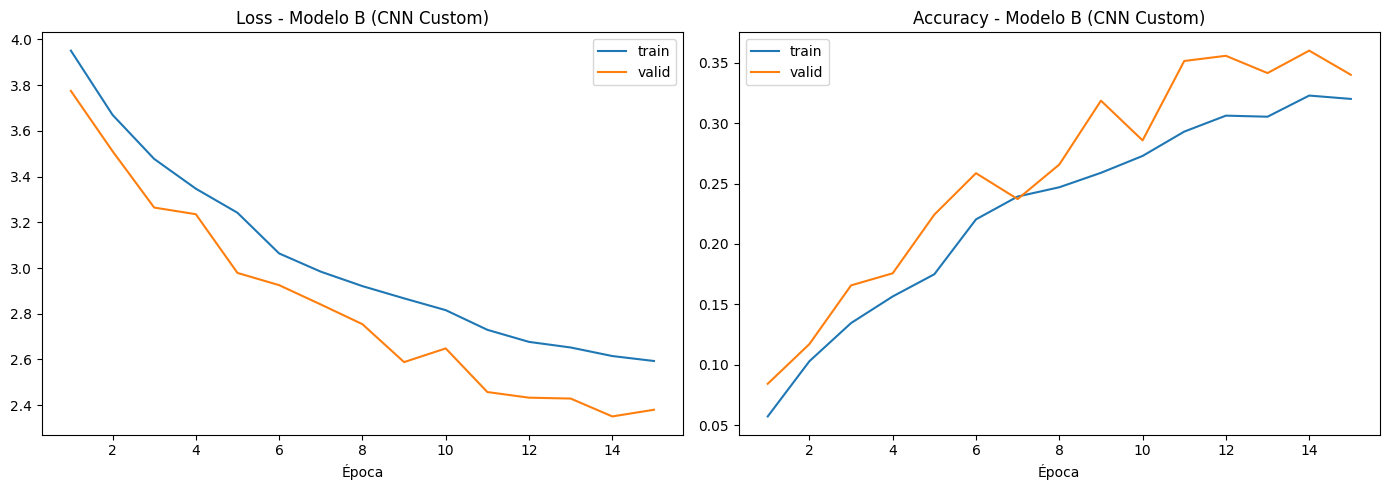

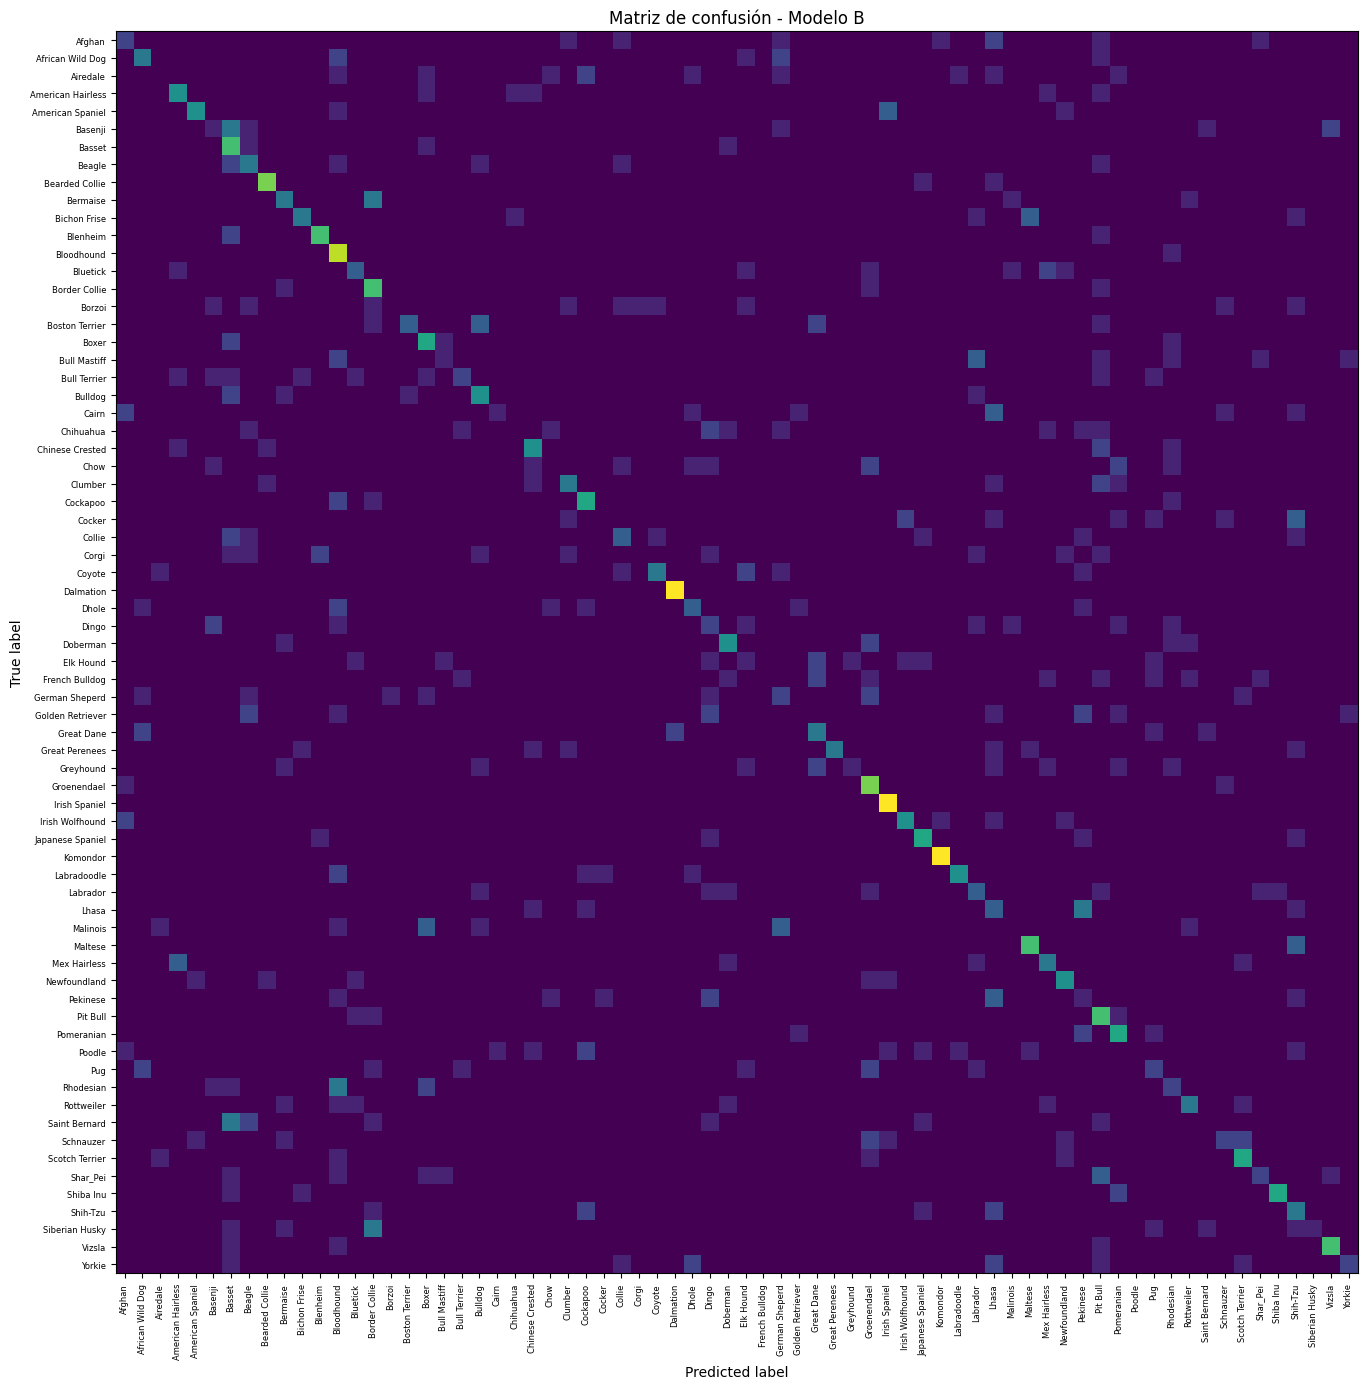

In [25]:
checkpoint_b = torch.load(
    classifier.checkpoints["cnn_custom"],
    map_location="cpu",
    weights_only=False,
)
history_b = checkpoint_b["history"]

epochs_axis_b = range(
    1,
    len(history_b["train_loss"]) + 1,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs_axis_b,
    history_b["train_loss"],
    label="train",
)
axes[0].plot(
    epochs_axis_b,
    history_b["valid_loss"],
    label="valid",
)
axes[0].set_title(
    "Loss - Modelo B (CNN Custom)"
)
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(
    epochs_axis_b,
    history_b["train_acc"],
    label="train",
)
axes[1].plot(
    epochs_axis_b,
    history_b["valid_acc"],
    label="valid",
)
axes[1].set_title(
    "Accuracy - Modelo B (CNN Custom)"
)
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "curves_model_b.png",
    dpi=100,
)
plt.show()


class_names_b = checkpoint_b[
    "class_names"
]

model_b = classifier._build_cnn_custom(
    len(class_names_b)
)
model_b.load_state_dict(
    checkpoint_b["model_state_dict"]
)
model_b.eval()

test_tf = classifier._build_transforms(
    train=False
)
test_ds_b = datasets.ImageFolder(
    settings.dataset_path / "test",
    transform=test_tf,
)
test_loader_b = DataLoader(
    test_ds_b,
    batch_size=settings.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

all_preds_b = []
all_labels_b = []

with torch.no_grad():
    for images, labels in test_loader_b:
        images = images.to(
            classifier.device
        )
        outputs = model_b(images)

        all_preds_b.extend(
            outputs.argmax(1)
            .cpu()
            .numpy()
        )
        all_labels_b.extend(
            labels.numpy()
        )

cm_b = confusion_matrix(
    all_labels_b,
    all_preds_b,
)

fig, ax = plt.subplots(
    figsize=(16, 14)
)

display_cm_b = ConfusionMatrixDisplay(
    confusion_matrix=cm_b,
    display_labels=class_names_b,
)

display_cm_b.plot(
    ax=ax,
    xticks_rotation=90,
    include_values=False,
    colorbar=False,
)

ax.set_title(
    "Matriz de confusión - Modelo B"
)
ax.tick_params(
    axis="both",
    labelsize=6,
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "confusion_matrix_b.png",
    dpi=100,
)
plt.show()


In [26]:
from IPython.display import Markdown, display


# ------------------------------------------------------------
# Resumen de las curvas
# ------------------------------------------------------------

epochs_b = len(history_b["train_loss"])

best_valid_loss_index_b = int(
    np.argmin(history_b["valid_loss"])
)

best_valid_acc_index_b = int(
    np.argmax(history_b["valid_acc"])
)

best_valid_loss_epoch_b = (
    best_valid_loss_index_b + 1
)

best_valid_acc_epoch_b = (
    best_valid_acc_index_b + 1
)

final_train_loss_b = float(
    history_b["train_loss"][-1]
)

final_valid_loss_b = float(
    history_b["valid_loss"][-1]
)

final_train_acc_b = float(
    history_b["train_acc"][-1]
)

final_valid_acc_b = float(
    history_b["valid_acc"][-1]
)


# ------------------------------------------------------------
# Clases con menor recall
# ------------------------------------------------------------

samples_per_class_b = cm_b.sum(axis=1)

recall_per_class_b = np.divide(
    np.diag(cm_b),
    samples_per_class_b,
    out=np.zeros_like(
        samples_per_class_b,
        dtype=float,
    ),
    where=samples_per_class_b != 0,
)

worst_indices_b = np.argsort(
    recall_per_class_b
)[:5]

worst_classes_b = [
    (
        class_names_b[index],
        float(recall_per_class_b[index]),
    )
    for index in worst_indices_b
]


# ------------------------------------------------------------
# Principales confusiones de esas clases
# ------------------------------------------------------------

confusion_lines_b = []

for class_index in worst_indices_b:
    row = cm_b[class_index].copy()
    row[class_index] = 0

    confused_index = int(np.argmax(row))
    confused_amount = int(row[confused_index])

    class_name = class_names_b[class_index]
    class_recall = recall_per_class_b[class_index]

    if confused_amount > 0:
        confusion_lines_b.append(
            f"- **{class_name}**: recall "
            f"{class_recall:.2f}; principal confusión con "
            f"**{class_names_b[confused_index]}** "
            f"({confused_amount} imágenes)."
        )
    else:
        confusion_lines_b.append(
            f"- **{class_name}**: recall "
            f"{class_recall:.2f}; sin una confusión "
            "predominante única."
        )


# ------------------------------------------------------------
# Interpretación prudente de la convergencia
# ------------------------------------------------------------

best_loss_is_last_epoch_b = (
    best_valid_loss_epoch_b == epochs_b
)

best_acc_is_last_epoch_b = (
    best_valid_acc_epoch_b == epochs_b
)

if (
    best_loss_is_last_epoch_b
    or best_acc_is_last_epoch_b
):
    convergence_interpretation_b = (
        "El mejor valor de validación se obtuvo al final del "
        "entrenamiento. Por lo tanto, no se observa evidencia "
        "clara de sobreajuste en las curvas; el modelo todavía "
        "podría beneficiarse de más épocas o de un ajuste de "
        "hiperparámetros."
    )

elif (
    final_valid_loss_b
    > history_b["valid_loss"][best_valid_loss_index_b]
    and final_train_loss_b
    < history_b["train_loss"][best_valid_loss_index_b]
):
    convergence_interpretation_b = (
        "Después de alcanzar su menor pérdida de validación, "
        "la pérdida de entrenamiento continuó descendiendo "
        "mientras la de validación empeoró. Este comportamiento "
        "es compatible con una etapa posterior de sobreajuste."
    )

else:
    convergence_interpretation_b = (
        "Las curvas muestran una evolución estable, sin una "
        "señal suficientemente clara para afirmar sobreajuste. "
        "La selección del checkpoint se realiza mediante el "
        "menor valor de valid_loss."
    )


display(
    Markdown(
        f"""
### Análisis Modelo B — CNN Custom

La CNN propia fue entrenada desde cero durante **{epochs_b} épocas**. Al finalizar,
alcanzó una accuracy de entrenamiento de **{final_train_acc_b:.4f}** y una
accuracy de validación de **{final_valid_acc_b:.4f}**. La pérdida final fue
**{final_train_loss_b:.4f}** en entrenamiento y **{final_valid_loss_b:.4f}**
en validación.

El menor `valid_loss` se obtuvo en la época
**{best_valid_loss_epoch_b}**, mientras que la mayor `valid_acc` se obtuvo
en la época **{best_valid_acc_epoch_b}**.

{convergence_interpretation_b}

Durante entrenamiento se aplican Data Augmentation y Dropout, mientras que
durante validación estas perturbaciones no se utilizan. Por ese motivo, una
accuracy de validación superior a la de entrenamiento no constituye por sí
sola evidencia de un error ni de fuga de datos.

Las cinco clases con menor recall fueron:

{chr(10).join(confusion_lines_b)}

La matriz de confusión muestra que los errores no se concentran necesariamente
en una única pareja de razas. El análisis debe basarse en las confusiones
observadas en esta ejecución y no únicamente en similitudes visuales asumidas.

En comparación con ResNet18, esta CNN parte de pesos aleatorios y debe aprender
simultáneamente características visuales y límites de decisión utilizando un
dataset relativamente pequeño de 70 clases. Esta diferencia constituye una
desventaja esperable frente al uso de transferencia de aprendizaje, pero forma
parte del objetivo comparativo solicitado en la consigna.
"""
    )
)


### Análisis Modelo B — CNN Custom

La CNN propia fue entrenada desde cero durante **15 épocas**. Al finalizar,
alcanzó una accuracy de entrenamiento de **0.3200** y una
accuracy de validación de **0.3400**. La pérdida final fue
**2.5932** en entrenamiento y **2.3799**
en validación.

El menor `valid_loss` se obtuvo en la época
**14**, mientras que la mayor `valid_acc` se obtuvo
en la época **14**.

Después de alcanzar su menor pérdida de validación, la pérdida de entrenamiento continuó descendiendo mientras la de validación empeoró. Este comportamiento es compatible con una etapa posterior de sobreajuste.

Durante entrenamiento se aplican Data Augmentation y Dropout, mientras que
durante validación estas perturbaciones no se utilizan. Por ese motivo, una
accuracy de validación superior a la de entrenamiento no constituye por sí
sola evidencia de un error ni de fuga de datos.

Las cinco clases con menor recall fueron:

- **Airedale**: recall 0.00; principal confusión con **Cockapoo** (2 imágenes).
- **Borzoi**: recall 0.00; principal confusión con **Basenji** (1 imágenes).
- **Corgi**: recall 0.00; principal confusión con **Blenheim** (2 imágenes).
- **Chihuahua**: recall 0.00; principal confusión con **Dingo** (2 imágenes).
- **Chow**: recall 0.00; principal confusión con **Groenendael** (2 imágenes).

La matriz de confusión muestra que los errores no se concentran necesariamente
en una única pareja de razas. El análisis debe basarse en las confusiones
observadas en esta ejecución y no únicamente en similitudes visuales asumidas.

En comparación con ResNet18, esta CNN parte de pesos aleatorios y debe aprender
simultáneamente características visuales y límites de decisión utilizando un
dataset relativamente pequeño de 70 clases. Esta diferencia constituye una
desventaja esperable frente al uso de transferencia de aprendizaje, pero forma
parte del objetivo comparativo solicitado en la consigna.


## 9. Estudio comparativo

Se comparan ambos modelos entrenados (ResNet18 Fine-Tuned y CNN Custom) en
metricas globales, clases con peor desempeño, y trade-offs de costo
computacional vs. performance. Las conclusiones de esta seccion se
trasladan al informe (`informe.ipynb`).

In [27]:
modelos_entrenados = [
    (
        "Modelo A - ResNet18 Fine-Tuned",
        checkpoint_a,
        history_a,
    ),
    (
        "Modelo B - CNN Custom",
        checkpoint_b,
        history_b,
    ),
]


for nombre, checkpoint, history in modelos_entrenados:
    if not history["valid_loss"] or not history["valid_acc"]:
        print(f"{nombre}: no posee historial de validación.")
        continue

    # np.argmin y np.argmax devuelven posiciones desde cero.
    # Se suma 1 para mostrar el número de época al usuario.
    best_loss_index = int(
        np.argmin(history["valid_loss"])
    )

    best_acc_index = int(
        np.argmax(history["valid_acc"])
    )

    best_loss_epoch_calculated = best_loss_index + 1
    best_acc_epoch = best_acc_index + 1

    # Los checkpoints generados con la nueva implementación de
    # train_classifier guardan directamente la época seleccionada
    # por menor valid_loss.
    #
    # El fallback permite que la celda también funcione con
    # checkpoints antiguos que todavía no contengan best_epoch.
    best_loss_epoch = int(
        checkpoint.get(
            "best_epoch",
            best_loss_epoch_calculated,
        )
    )

    epochs_trained = int(
        checkpoint.get(
            "epochs_trained",
            len(history["valid_loss"]),
        )
    )

    best_valid_loss = float(
        checkpoint.get(
            "best_valid_loss",
            history["valid_loss"][best_loss_index],
        )
    )

    best_valid_acc = float(
        history["valid_acc"][best_acc_index]
    )

    print(nombre)
    print(f"- Épocas ejecutadas: {epochs_trained}")
    print(
        f"- Mejor valid_loss: {best_valid_loss:.4f} "
        f"en la época {best_loss_epoch}"
    )
    print(
        f"- Mejor valid_acc: {best_valid_acc:.4f} "
        f"en la época {best_acc_epoch}"
    )
    print(
        "- Coinciden ambas épocas: "
        f"{best_loss_epoch == best_acc_epoch}"
    )
    print()

Modelo A - ResNet18 Fine-Tuned
- Épocas ejecutadas: 13
- Mejor valid_loss: 0.1269 en la época 9
- Mejor valid_acc: 0.9614 en la época 10
- Coinciden ambas épocas: False

Modelo B - CNN Custom
- Épocas ejecutadas: 15
- Mejor valid_loss: 2.3507 en la época 14
- Mejor valid_acc: 0.3600 en la época 14
- Coinciden ambas épocas: True



In [28]:
comparison = pd.DataFrame([metrics_a, metrics_b], index=["ResNet18 Fine-Tuned", "CNN Custom"])
comparison

,accuracy,precision,recall,specificity,f1
ResNet18 Fine-Tuned,0.958571,0.960078,0.958571,0.99940,0.956634
CNN Custom,0.371429,0.370877,0.371429,0.99089,0.342359


In [29]:
def medir_tiempo_inferencia(
    model,
    device,
    image_size,
    n_iter=100,
    warmup_iter=10,
):
    """
    Mide el tiempo promedio de una inferencia con batch size 1.

    La sincronización es necesaria en CUDA porque las operaciones
    de GPU se ejecutan de manera asincrónica.
    """
    model.eval()

    dummy = torch.randn(
        1,
        3,
        image_size,
        image_size,
        device=device,
    )

    with torch.no_grad():
        # Warm-up para evitar incluir inicializaciones internas
        # en la medición.
        for _ in range(warmup_iter):
            model(dummy)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(n_iter):
            model(dummy)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

    return elapsed / n_iter * 1000


def contar_parametros_totales(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


def contar_parametros_entrenables(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


tiempo_a = medir_tiempo_inferencia(
    model=model_a,
    device=classifier.device,
    image_size=settings.image_size,
)

tiempo_b = medir_tiempo_inferencia(
    model=model_b,
    device=classifier.device,
    image_size=settings.image_size,
)


tradeoffs = pd.DataFrame(
    {
        "Modelo": [
            "ResNet18 Fine-Tuned",
            "CNN Custom",
        ],
        "Parámetros totales": [
            contar_parametros_totales(model_a),
            contar_parametros_totales(model_b),
        ],
        "Parámetros entrenables": [
            contar_parametros_entrenables(model_a),
            contar_parametros_entrenables(model_b),
        ],
        "Tiempo inferencia (ms)": [
            tiempo_a,
            tiempo_b,
        ],
        "Accuracy test": [
            metrics_a["accuracy"],
            metrics_b["accuracy"],
        ],
        "F1 macro test": [
            metrics_a["f1"],
            metrics_b["f1"],
        ],
    }
)


tradeoffs

,Modelo,Parámetros totales,Parámetros entrenables,Tiempo inferencia (ms),Accuracy test,F1 macro test
0,ResNet18 Fine-Tuned,11212422,8429638,2.937374,0.958571,0.956634
1,CNN Custom,407366,407366,0.722054,0.371429,0.342359


In [30]:
from IPython.display import Markdown, display


row_a = tradeoffs.loc[
    tradeoffs["Modelo"] == "ResNet18 Fine-Tuned"
].iloc[0]

row_b = tradeoffs.loc[
    tradeoffs["Modelo"] == "CNN Custom"
].iloc[0]


accuracy_a = float(row_a["Accuracy test"])
accuracy_b = float(row_b["Accuracy test"])

f1_a = float(row_a["F1 macro test"])
f1_b = float(row_b["F1 macro test"])

params_total_a = int(row_a["Parámetros totales"])
params_total_b = int(row_b["Parámetros totales"])

params_trainable_a = int(
    row_a["Parámetros entrenables"]
)

params_trainable_b = int(
    row_b["Parámetros entrenables"]
)

time_a = float(row_a["Tiempo inferencia (ms)"])
time_b = float(row_b["Tiempo inferencia (ms)"])


speed_ratio = (
    time_a / time_b
    if time_b > 0
    else float("nan")
)

parameter_ratio = (
    params_total_a / params_total_b
    if params_total_b > 0
    else float("nan")
)


display(
    Markdown(
        f"""
### Trade-offs entre modelos

**ResNet18 Fine-Tuned** obtuvo una accuracy de
**{accuracy_a:.2%}** y un F1 macro de **{f1_a:.4f}**. La arquitectura posee
**{params_total_a:,} parámetros totales**, de los cuales
**{params_trainable_a:,} fueron entrenables con la estrategia de fine-tuning
parcial. Su tiempo promedio de inferencia fue de **{time_a:.2f} ms** por
imagen con batch size 1.

**CNN Custom** obtuvo una accuracy de **{accuracy_b:.2%}** y un F1 macro de
**{f1_b:.4f}**. Posee **{params_total_b:,} parámetros totales**, todos
entrenables, y registró un tiempo promedio de inferencia de
**{time_b:.2f} ms** por imagen.

La CNN propia utiliza aproximadamente **{parameter_ratio:.1f} veces menos
parámetros totales** y, en esta medición, ResNet18 requirió aproximadamente
**{speed_ratio:.2f} veces más tiempo de inferencia**. Sin embargo, la reducción
de costo computacional de la CNN estuvo acompañada por una disminución
considerable en accuracy y F1.

Para este dataset y esta configuración experimental, ResNet18 Fine-Tuned ofrece
el mejor compromiso cuando la prioridad es la calidad de clasificación. La CNN
Custom es más compacta y rápida, pero su rendimiento resulta insuficiente para
reemplazar al modelo preentrenado en la aplicación final.

Los tiempos informados dependen del hardware, del backend de PyTorch y de la
carga del sistema. Por lo tanto, deben interpretarse como una comparación
realizada en el mismo entorno y no como tiempos universales de ambos modelos.
"""
    )
)


### Trade-offs entre modelos

**ResNet18 Fine-Tuned** obtuvo una accuracy de
**95.86%** y un F1 macro de **0.9566**. La arquitectura posee
**11,212,422 parámetros totales**, de los cuales
**8,429,638 fueron entrenables con la estrategia de fine-tuning
parcial. Su tiempo promedio de inferencia fue de **2.94 ms** por
imagen con batch size 1.

**CNN Custom** obtuvo una accuracy de **37.14%** y un F1 macro de
**0.3424**. Posee **407,366 parámetros totales**, todos
entrenables, y registró un tiempo promedio de inferencia de
**0.72 ms** por imagen.

La CNN propia utiliza aproximadamente **27.5 veces menos
parámetros totales** y, en esta medición, ResNet18 requirió aproximadamente
**4.07 veces más tiempo de inferencia**. Sin embargo, la reducción
de costo computacional de la CNN estuvo acompañada por una disminución
considerable en accuracy y F1.

Para este dataset y esta configuración experimental, ResNet18 Fine-Tuned ofrece
el mejor compromiso cuando la prioridad es la calidad de clasificación. La CNN
Custom es más compacta y rápida, pero su rendimiento resulta insuficiente para
reemplazar al modelo preentrenado en la aplicación final.

Los tiempos informados dependen del hardware, del backend de PyTorch y de la
carga del sistema. Por lo tanto, deben interpretarse como una comparación
realizada en el mismo entorno y no como tiempos universales de ambos modelos.


### Clases peor clasificadas:

In [31]:
def peores_clases(cm, class_names, top_n=5):
    """
    Para cada clase, calcula recall (sensibilidad) y la cantidad de falsos
    positivos que genera en otras clases. Devuelve las top_n clases con
    peor recall, que son las que el modelo confunde mas seguido.
    """
    recalls = np.divide(
        cm.diagonal(),
        cm.sum(axis=1),
        out=np.zeros(
            cm.shape[0],
            dtype=float,
        ),
        where=cm.sum(axis=1) != 0,
    )
    falsos_positivos = cm.sum(axis=0) - cm.diagonal()

    df = pd.DataFrame({
        "clase": class_names,
        "recall": recalls,
        "falsos_positivos": falsos_positivos,
        "n_muestras": cm.sum(axis=1),
    }).sort_values("recall")

    return df.head(top_n)

print("Modelo A - peores 5 clases por recall:")
peores_a = peores_clases(cm, class_names)
print(peores_a)

print("\nModelo B - peores 5 clases por recall:")
peores_b = peores_clases(cm_b, class_names_b)
print(peores_b)

Modelo A - peores 5 clases por recall:
               clase  recall  falsos_positivos  n_muestras
50          Malinois     0.3                 1          10
20           Bulldog     0.7                 1          10
4   American Spaniel     0.8                 1          10
7             Beagle     0.9                 1          10
24              Chow     0.9                 0          10

Modelo B - peores 5 clases por recall:
        clase  recall  falsos_positivos  n_muestras
2    Airedale     0.0                 3          10
15     Borzoi     0.0                 1          10
29      Corgi     0.0                 1          10
22  Chihuahua     0.0                 2          10
24       Chow     0.0                 4          10


In [32]:
def top_confusiones(cm, class_names, peores_df, top_n_confusiones=3):
    filas = []
    for clase in peores_df["clase"]:
        i = class_names.index(clase)
        fila = cm[i].copy()
        fila[i] = 0  # excluir la diagonal (aciertos)
        top_idx = np.argsort(fila)[::-1][:top_n_confusiones]
        confusiones = [(class_names[j], int(fila[j])) for j in top_idx if fila[j] > 0]
        filas.append({"clase": clase, "confundida_con": confusiones})
    return pd.DataFrame(filas)

print("Modelo A:")
print(top_confusiones(cm, class_names, peores_a))
print("\nModelo B:")
print(top_confusiones(cm_b, class_names_b, peores_b))

Modelo A:
              clase                                     confundida_con
0          Malinois  [(German Sheperd, 4), (Great Dane, 2), (Dingo,...
1           Bulldog         [(Boston Terrier, 2), (French Bulldog, 1)]
2  American Spaniel                               [(Irish Spaniel, 2)]
3            Beagle                                    [(Bluetick, 1)]
4              Chow                                  [(Pomeranian, 1)]

Modelo B:
       clase                                     confundida_con
0   Airedale            [(Cockapoo, 2), (Boxer, 1), (Lhasa, 1)]
1     Borzoi         [(Shih-Tzu, 1), (Clumber, 1), (Beagle, 1)]
2      Corgi        [(Blenheim, 2), (Beagle, 1), (Labrador, 1)]
3  Chihuahua     [(Dingo, 2), (Doberman, 1), (Mex Hairless, 1)]
4       Chow  [(Groenendael, 2), (Pomeranian, 2), (Rhodesian...


### Evaluación contra el conjunto independiente (`external_eval`)

El conjunto externo contiene imágenes de solo cinco de las setenta razas conocidas
por los modelos. Por ese motivo, esta evaluación no reemplaza la evaluación
principal sobre `test`, que contiene las setenta clases.

En esta sección se reportan:

- accuracy top-1 sobre todas las imágenes externas;
- recall macro de las cinco razas presentes;
- recall individual por raza;
- cantidad de predicciones dirigidas a razas que no forman parte del conjunto externo;
- detalle de las clasificaciones incorrectas.

No se utiliza la precision macro restringida a las cinco razas como indicador
principal, porque el modelo puede predecir cualquiera de las setenta clases y
ese valor podría resultar artificialmente alto al excluir del promedio las
clases ausentes en el conjunto externo.

In [33]:
def evaluar_contra_externo(
    classifier_service,
    model,
    external_path,
    class_names,
):
    """
    Evalúa un modelo de 70 clases sobre un conjunto externo que
    contiene solamente un subconjunto de esas razas.

    Devuelve:
    - accuracy top-1;
    - recall macro de las razas presentes;
    - recall por raza;
    - predicciones fuera del subconjunto externo;
    - detalle individual de las predicciones.
    """
    model = model.to(
        classifier_service.device
    )
    model.eval()

    test_tf = classifier_service._build_transforms(
        train=False
    )

    external_ds = datasets.ImageFolder(
        external_path,
        transform=test_tf,
    )

    clases_externas = set(external_ds.classes)
    clases_checkpoint = set(class_names)

    no_reconocidas = (
        clases_externas - clases_checkpoint
    )

    if no_reconocidas:
        raise ValueError(
            "El conjunto externo contiene razas que el "
            f"modelo no conoce: {sorted(no_reconocidas)}. "
            "Revisar los nombres de las carpetas."
        )

    external_loader = DataLoader(
        external_ds,
        batch_size=(
            classifier_service
            .settings
            .batch_size
        ),
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    all_preds = []
    all_labels = []
    all_paths = []

    if len(external_ds) == 0:
        raise ValueError(
            "El conjunto externo no contiene imágenes."
        )

    offset = 0

    with torch.no_grad():
        for images, labels in external_loader:
            images = images.to(
                classifier_service.device
            )

            outputs = model(images)

            preds = (
                outputs.argmax(dim=1)
                .cpu()
                .numpy()
            )

            labels_locales = labels.numpy()

            labels_remapeadas = [
                class_names.index(
                    external_ds.classes[label_local]
                )
                for label_local in labels_locales
            ]

            batch_size_actual = len(labels_locales)

            batch_paths = [
                external_ds.samples[index][0]
                for index in range(
                    offset,
                    offset + batch_size_actual,
                )
            ]

            offset += batch_size_actual

            all_preds.extend(preds.tolist())
            all_labels.extend(labels_remapeadas)
            all_paths.extend(batch_paths)

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    labels_presentes = sorted(
        class_names.index(class_name)
        for class_name in clases_externas
    )

    accuracy = float(
        np.mean(all_preds == all_labels)
    )

    recalls = {}

    for label_index in labels_presentes:
        mascara_clase = all_labels == label_index
        total_clase = int(mascara_clase.sum())

        aciertos_clase = int(
            np.logical_and(
                mascara_clase,
                all_preds == label_index,
            ).sum()
        )

        recall_clase = (
            aciertos_clase / total_clase
            if total_clase > 0
            else 0.0
        )

        recalls[class_names[label_index]] = float(
            recall_clase
        )

    recall_macro = float(
        np.mean(list(recalls.values()))
    )

    predicciones_fuera_subconjunto = int(
        np.sum(
            ~np.isin(
                all_preds,
                labels_presentes,
            )
        )
    )

    porcentaje_fuera_subconjunto = float(
        predicciones_fuera_subconjunto
        / len(all_preds)
    )

    detalle = pd.DataFrame(
        {
            "archivo": [
                Path(path).name
                for path in all_paths
            ],
            "raza_real": [
                class_names[index]
                for index in all_labels
            ],
            "raza_predicha": [
                class_names[index]
                for index in all_preds
            ],
            "correcta": all_preds == all_labels,
            "prediccion_fuera_subconjunto": [
                prediction not in labels_presentes
                for prediction in all_preds
            ],
        }
    )

    resumen = {
        "accuracy_top1": accuracy,
        "recall_macro_razas_presentes": recall_macro,
        "predicciones_fuera_subconjunto":
            predicciones_fuera_subconjunto,
        "porcentaje_fuera_subconjunto":
            porcentaje_fuera_subconjunto,
        "n_clases_evaluadas":
            len(labels_presentes),
        "n_imagenes":
            len(all_labels),
    }

    return resumen, recalls, detalle

In [34]:
class_names = checkpoint_a[
    "class_names"
]

if checkpoint_b["class_names"] != class_names:
    raise ValueError(
        "Los checkpoints de ambos modelos no "
        "contienen el mismo orden de clases."
    )


# ------------------------------------------------------------
# Modelo A - ResNet18 Fine-Tuned
# ------------------------------------------------------------

model_a_external = (
    classifier._build_resnet18_finetuned(
        len(class_names)
    )
)

model_a_external.load_state_dict(
    checkpoint_a["model_state_dict"]
)
model_a_external.eval()

(
    metrics_a_external,
    recalls_a_external,
    detail_a_external,
) = evaluar_contra_externo(
    classifier_service=classifier,
    model=model_a_external,
    external_path=EXTERNAL_SET_PATH,
    class_names=class_names,
)


# ------------------------------------------------------------
# Modelo B - CNN Custom
# ------------------------------------------------------------

model_b_external = (
    classifier._build_cnn_custom(
        len(class_names)
    )
)

model_b_external.load_state_dict(
    checkpoint_b["model_state_dict"]
)
model_b_external.eval()

(
    metrics_b_external,
    recalls_b_external,
    detail_b_external,
) = evaluar_contra_externo(
    classifier_service=classifier,
    model=model_b_external,
    external_path=EXTERNAL_SET_PATH,
    class_names=class_names,
)


# ------------------------------------------------------------
# Comparación general
# ------------------------------------------------------------

comparison_external = pd.DataFrame(
    [
        metrics_a_external,
        metrics_b_external,
    ],
    index=[
        "ResNet18 Fine-Tuned",
        "CNN Custom",
    ],
)

display(comparison_external)


# ------------------------------------------------------------
# Recall por raza
# ------------------------------------------------------------

recall_external = pd.DataFrame(
    {
        "ResNet18 Fine-Tuned":
            recalls_a_external,
        "CNN Custom":
            recalls_b_external,
    }
)

recall_external.index.name = "Raza real"

display(recall_external)


# ------------------------------------------------------------
# Clasificaciones incorrectas
# ------------------------------------------------------------

print(
    "Errores de ResNet18 Fine-Tuned:"
)

display(
    detail_a_external.loc[
        ~detail_a_external["correcta"]
    ].reset_index(drop=True)
)

print(
    "Errores de CNN Custom:"
)

display(
    detail_b_external.loc[
        ~detail_b_external["correcta"]
    ].reset_index(drop=True)
)


,accuracy_top1,recall_macro_razas_presentes,predicciones_fuera_subconjunto,porcentaje_fuera_subconjunto,n_clases_evaluadas,n_imagenes
ResNet18 Fine-Tuned,0.538462,0.533333,12,0.461538,5,26
CNN Custom,0.153846,0.140000,22,0.846154,5,26


,ResNet18 Fine-Tuned,CNN Custom
Raza real,,
Basset,0.400000,0.0
Border Collie,0.400000,0.0
Doberman,0.666667,0.5
Golden Retriever,1.000000,0.2
Poodle,0.200000,0.0


Errores de ResNet18 Fine-Tuned:


,archivo,raza_real,raza_predicha,correcta,prediccion_fuera_subconjunto
0,Captura de pantalla 2026-06-25 130343.png,Basset,German Sheperd,False,True
1,Captura de pantalla 2026-06-25 130359.png,Basset,Bermaise,False,True
2,Captura de pantalla 2026-06-25 130524.png,Basset,Corgi,False,True
3,Captura de pantalla 2026-06-21 204717.png,Border Collie,Bulldog,False,True
4,Captura de pantalla 2026-06-21 204742.png,Border Collie,Siberian Husky,False,True
5,Captura de pantalla 2026-06-25 125136.png,Border Collie,Siberian Husky,False,True
6,Captura de pantalla 2026-06-25 125926.png,Doberman,Great Dane,False,True
7,Captura de pantalla 2026-06-25 130020.png,Doberman,Labrador,False,True
8,Captura de pantalla 2026-06-21 205133.png,Poodle,Chinese Crested,False,True
9,Captura de pantalla 2026-06-21 205145.png,Poodle,Dingo,False,True


Errores de CNN Custom:


,archivo,raza_real,raza_predicha,correcta,prediccion_fuera_subconjunto
0,Captura de pantalla 2026-06-25 130312.png,Basset,Dhole,False,True
1,Captura de pantalla 2026-06-25 130326.png,Basset,Great Dane,False,True
2,Captura de pantalla 2026-06-25 130343.png,Basset,Great Dane,False,True
3,Captura de pantalla 2026-06-25 130359.png,Basset,Great Dane,False,True
4,Captura de pantalla 2026-06-25 130524.png,Basset,Mex Hairless,False,True
5,Captura de pantalla 2026-06-21 204655.png,Border Collie,Great Dane,False,True
6,Captura de pantalla 2026-06-21 204717.png,Border Collie,Bulldog,False,True
7,Captura de pantalla 2026-06-21 204742.png,Border Collie,Bulldog,False,True
8,Captura de pantalla 2026-06-25 124749.png,Border Collie,Great Dane,False,True
9,Captura de pantalla 2026-06-25 125136.png,Border Collie,Great Dane,False,True


## 10. Verificación y descarga de los checkpoints

La Etapa 2 genera un checkpoint para cada uno de los dos modelos evaluados:

- ResNet18 con fine-tuning parcial.
- CNN propia entrenada desde cero.

Ambos archivos deben conservarse porque el backend permite seleccionar
dinámicamente el modelo activo. En Google Colab se descargarán los dos
checkpoints; en ejecución local se informarán sus rutas de almacenamiento.

In [35]:
# ------------------------------------------------------------
# Verificación de los dos checkpoints obligatorios
# ------------------------------------------------------------

checkpoint_paths = {
    "ResNet18 Fine-Tuned": (
        settings.model_path
        / settings.resnet18_model_name
    ),
    "CNN Custom": (
        settings.model_path
        / settings.cnn_custom_model_name
    ),
}


missing_checkpoints = []

for model_name, checkpoint_path in checkpoint_paths.items():
    if checkpoint_path.is_file():
        size_mb = (
            checkpoint_path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"{model_name}: {checkpoint_path} "
            f"({size_mb:.2f} MB)"
        )

    else:
        missing_checkpoints.append(
            (model_name, checkpoint_path)
        )

        print(
            f"{model_name}: checkpoint no encontrado "
            f"en {checkpoint_path}"
        )


if missing_checkpoints:
    missing_description = ", ".join(
        model_name
        for model_name, _ in missing_checkpoints
    )

    raise FileNotFoundError(
        "Faltan checkpoints obligatorios: "
        f"{missing_description}. "
        "Entrenar ambos modelos antes de continuar."
    )


# ------------------------------------------------------------
# Descarga en Google Colab
# ------------------------------------------------------------

if IN_COLAB:
    from google.colab import files

    for model_name, checkpoint_path in checkpoint_paths.items():
        print(f"Descargando {model_name}...")
        files.download(str(checkpoint_path))

else:
    print()
    print(
        "Ejecución local: los checkpoints permanecen "
        "guardados en:"
    )

    for checkpoint_path in checkpoint_paths.values():
        print(f"- {checkpoint_path.resolve()}")

ResNet18 Fine-Tuned: ../models/resnet18_finetuned.pth (42.85 MB)
CNN Custom: ../models/cnn_custom.pth (1.57 MB)
Descargando ResNet18 Fine-Tuned...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando CNN Custom...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
from IPython.display import Markdown, display


# ------------------------------------------------------------
# Resultados internos sobre test
# ------------------------------------------------------------

accuracy_a = float(metrics_a["accuracy"])
precision_a = float(metrics_a["precision"])
recall_a = float(metrics_a["recall"])
specificity_a = float(metrics_a["specificity"])
f1_a = float(metrics_a["f1"])

accuracy_b = float(metrics_b["accuracy"])
precision_b = float(metrics_b["precision"])
recall_b = float(metrics_b["recall"])
specificity_b = float(metrics_b["specificity"])
f1_b = float(metrics_b["f1"])


# ------------------------------------------------------------
# Información del entrenamiento
# ------------------------------------------------------------

epochs_a = len(history_a["valid_loss"])
epochs_b = len(history_b["valid_loss"])

best_epoch_a = int(
    checkpoint_a.get(
        "best_epoch",
        np.argmin(history_a["valid_loss"]) + 1,
    )
)

best_epoch_b = int(
    checkpoint_b.get(
        "best_epoch",
        np.argmin(history_b["valid_loss"]) + 1,
    )
)


# ------------------------------------------------------------
# Costo computacional
# ------------------------------------------------------------

tradeoff_a = tradeoffs.loc[
    tradeoffs["Modelo"] == "ResNet18 Fine-Tuned"
].iloc[0]

tradeoff_b = tradeoffs.loc[
    tradeoffs["Modelo"] == "CNN Custom"
].iloc[0]

params_a = int(
    tradeoff_a["Parámetros totales"]
)

params_b = int(
    tradeoff_b["Parámetros totales"]
)

time_a = float(
    tradeoff_a["Tiempo inferencia (ms)"]
)

time_b = float(
    tradeoff_b["Tiempo inferencia (ms)"]
)


# ------------------------------------------------------------
# Evaluación externa
# ------------------------------------------------------------

external_accuracy_a = float(
    metrics_a_external["accuracy_top1"]
)

external_recall_a = float(
    metrics_a_external[
        "recall_macro_razas_presentes"
    ]
)

external_accuracy_b = float(
    metrics_b_external["accuracy_top1"]
)

external_recall_b = float(
    metrics_b_external[
        "recall_macro_razas_presentes"
    ]
)

external_images = int(
    metrics_a_external["n_imagenes"]
)

external_classes = int(
    metrics_a_external["n_clases_evaluadas"]
)


# ------------------------------------------------------------
# Selección basada en los resultados
# ------------------------------------------------------------

if (
    accuracy_a > accuracy_b
    and f1_a > f1_b
):
    selected_model = "ResNet18 Fine-Tuned"

    selection_reason = (
        "obtuvo simultáneamente la mayor accuracy y el mayor "
        "F1 macro sobre el conjunto de prueba"
    )

elif (
    accuracy_b > accuracy_a
    and f1_b > f1_a
):
    selected_model = "CNN Custom"

    selection_reason = (
        "obtuvo simultáneamente la mayor accuracy y el mayor "
        "F1 macro sobre el conjunto de prueba"
    )

else:
    selected_model = (
        "ResNet18 Fine-Tuned"
        if f1_a >= f1_b
        else "CNN Custom"
    )

    selection_reason = (
        "presentó el mejor F1 macro, priorizando un rendimiento "
        "equilibrado entre las 70 clases"
    )


# ------------------------------------------------------------
# Conclusión final automática
# ------------------------------------------------------------

display(
    Markdown(
        f"""
## Conclusión general de la Etapa 2

Se entrenaron y evaluaron los dos enfoques solicitados: una
**ResNet18 con fine-tuning parcial** y una **CNN propia entrenada desde
cero**. La evaluación principal se realizó sobre el conjunto `test`,
manteniéndolo separado de los conjuntos de entrenamiento y validación.

En el conjunto de prueba, **ResNet18 Fine-Tuned** obtuvo:

- Accuracy: **{accuracy_a:.4f}**
- Precision macro: **{precision_a:.4f}**
- Recall macro: **{recall_a:.4f}**
- Specificity macro: **{specificity_a:.4f}**
- F1 macro: **{f1_a:.4f}**

Por su parte, **CNN Custom** obtuvo:

- Accuracy: **{accuracy_b:.4f}**
- Precision macro: **{precision_b:.4f}**
- Recall macro: **{recall_b:.4f}**
- Specificity macro: **{specificity_b:.4f}**
- F1 macro: **{f1_b:.4f}**

La specificity fue calculada mediante un esquema one-vs-rest para cada
raza y luego promediada. Debido a que el problema contiene 70 clases,
cada cálculo incluye una gran cantidad de verdaderos negativos. Por eso,
esta métrica debe analizarse junto con accuracy, recall, F1 y las matrices
de confusión, y no de manera aislada.

ResNet18 ejecutó **{epochs_a} épocas** y el checkpoint seleccionado por
menor pérdida de validación correspondió a la época **{best_epoch_a}**.
La CNN propia ejecutó **{epochs_b} épocas** y su mejor checkpoint
correspondió a la época **{best_epoch_b}**. Las curvas permiten observar
el comportamiento de entrenamiento y validación durante todas las épocas
ejecutadas, mientras que las matrices de confusión muestran que el
rendimiento no es uniforme entre todas las razas.

La comparación de costo computacional mostró que ResNet18 posee
**{params_a:,} parámetros** y registró un tiempo promedio de inferencia de
**{time_a:.2f} ms** por imagen. La CNN propia posee **{params_b:,}
parámetros** y registró **{time_b:.2f} ms**. La CNN es más compacta, pero
esa reducción debe analizarse en conjunto con la diferencia de rendimiento
predictivo. Los tiempos dependen del hardware utilizado y solo representan
una comparación bajo el mismo entorno experimental.

En el conjunto independiente, compuesto por **{external_images} imágenes
de {external_classes} razas**, ResNet18 obtuvo una accuracy top-1 de
**{external_accuracy_a:.4f}** y un recall macro de
**{external_recall_a:.4f}**. La CNN propia obtuvo una accuracy top-1 de
**{external_accuracy_b:.4f}** y un recall macro de
**{external_recall_b:.4f}**.

Esta evaluación externa es complementaria: permite observar el
comportamiento frente a imágenes obtenidas fuera del dataset principal,
pero no reemplaza al conjunto `test` porque contiene solamente un
subconjunto de las 70 razas.

A partir de los resultados obtenidos, el modelo recomendado para la
integración en la aplicación es **{selected_model}**, ya que
{selection_reason}. El otro modelo se conserva como enfoque comparativo y
como alternativa de menor o diferente costo computacional.

En síntesis, el experimento muestra la ventaja de la transferencia de
aprendizaje cuando se dispone de un dataset relativamente limitado y un
problema multiclase amplio. La CNN propia permite estudiar el entrenamiento
desde cero, pero su rendimiento depende en mayor medida de la cantidad de
datos, la arquitectura seleccionada y el ajuste de hiperparámetros.
"""
    )
)


## Conclusión general de la Etapa 2

Se entrenaron y evaluaron los dos enfoques solicitados: una
**ResNet18 con fine-tuning parcial** y una **CNN propia entrenada desde
cero**. La evaluación principal se realizó sobre el conjunto `test`,
manteniéndolo separado de los conjuntos de entrenamiento y validación.

En el conjunto de prueba, **ResNet18 Fine-Tuned** obtuvo:

- Accuracy: **0.9586**
- Precision macro: **0.9601**
- Recall macro: **0.9586**
- Specificity macro: **0.9994**
- F1 macro: **0.9566**

Por su parte, **CNN Custom** obtuvo:

- Accuracy: **0.3714**
- Precision macro: **0.3709**
- Recall macro: **0.3714**
- Specificity macro: **0.9909**
- F1 macro: **0.3424**

La specificity fue calculada mediante un esquema one-vs-rest para cada
raza y luego promediada. Debido a que el problema contiene 70 clases,
cada cálculo incluye una gran cantidad de verdaderos negativos. Por eso,
esta métrica debe analizarse junto con accuracy, recall, F1 y las matrices
de confusión, y no de manera aislada.

ResNet18 ejecutó **13 épocas** y el checkpoint seleccionado por
menor pérdida de validación correspondió a la época **9**.
La CNN propia ejecutó **15 épocas** y su mejor checkpoint
correspondió a la época **14**. Las curvas permiten observar
el comportamiento de entrenamiento y validación durante todas las épocas
ejecutadas, mientras que las matrices de confusión muestran que el
rendimiento no es uniforme entre todas las razas.

La comparación de costo computacional mostró que ResNet18 posee
**11,212,422 parámetros** y registró un tiempo promedio de inferencia de
**2.94 ms** por imagen. La CNN propia posee **407,366
parámetros** y registró **0.72 ms**. La CNN es más compacta, pero
esa reducción debe analizarse en conjunto con la diferencia de rendimiento
predictivo. Los tiempos dependen del hardware utilizado y solo representan
una comparación bajo el mismo entorno experimental.

En el conjunto independiente, compuesto por **26 imágenes
de 5 razas**, ResNet18 obtuvo una accuracy top-1 de
**0.5385** y un recall macro de
**0.5333**. La CNN propia obtuvo una accuracy top-1 de
**0.1538** y un recall macro de
**0.1400**.

Esta evaluación externa es complementaria: permite observar el
comportamiento frente a imágenes obtenidas fuera del dataset principal,
pero no reemplaza al conjunto `test` porque contiene solamente un
subconjunto de las 70 razas.

A partir de los resultados obtenidos, el modelo recomendado para la
integración en la aplicación es **ResNet18 Fine-Tuned**, ya que
obtuvo simultáneamente la mayor accuracy y el mayor F1 macro sobre el conjunto de prueba. El otro modelo se conserva como enfoque comparativo y
como alternativa de menor o diferente costo computacional.

En síntesis, el experimento muestra la ventaja de la transferencia de
aprendizaje cuando se dispone de un dataset relativamente limitado y un
problema multiclase amplio. La CNN propia permite estudiar el entrenamiento
desde cero, pero su rendimiento depende en mayor medida de la cantidad de
datos, la arquitectura seleccionada y el ajuste de hiperparámetros.
